(WITH VALIDATION)(20epoch) 70-15-15 Split. Trivial Augmentation --> Tiny Swin v2 --> Attention Guided Mixup --> ViT Head(LoRA Linear) --> PolyLoss + LabelSmoothing --> SAM + Cosine LR --> TTA

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

e:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

Device: cpu


In [ ]:
DATASET_DIR = 'dataset'
IMG_SIZE = 224
FEATURE_CSV_DIR = '.'

# discover classes
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print('Classes:', CLASS_NAMES)

# collect paths
image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    for p in imgs:
        image_paths.append(p)
        labels.append(lbl)

# encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# ================================
# 70-15-15 Split (Stratified)
# ================================
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.30, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.50, random_state=42
)

print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

# save test metadata
pd.DataFrame({'path': X_test_paths, 'label': y_test}).to_csv(os.path.join(FEATURE_CSV_DIR, 'X_test_raw.csv'), index=False)
pd.DataFrame({'label': y_test}).to_csv(os.path.join(FEATURE_CSV_DIR, 'y_test.csv'), index=False)

Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 2800  Val: 600  Test: 600


In [4]:
# ================================
# Augmentations
# ================================
try:
    from torchvision.transforms import TrivialAugmentWide
    trivial = TrivialAugmentWide()
    print('TrivialAugmentWide available.')
except Exception:
    trivial = None
    print('TrivialAugmentWide not available — using fallback RandomChoice.')

train_base = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
if trivial is not None:
    train_transforms = transforms.Compose(train_base + [trivial, transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])
else:
    fallback_aug = transforms.RandomChoice([
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomAffine(degrees=0, translate=(0.05,0.05)),
    ])
    train_transforms = transforms.Compose(train_base + [fallback_aug, transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize([0.5]*3, [0.5]*3)
])

TrivialAugmentWide available.


In [5]:
# ================================
# Feature Extractor (Swin Tiny)
# ================================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

# extract features
X_train_feats = np.stack([extract_feature_from_path(p, train_transforms) for p in tqdm(X_train_paths, desc="Train feats")])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths, desc="Val feats")])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths, desc="Test feats")])

Test feats: 100%|██████████| 600/600 [02:05<00:00,  4.78it/s]


In [6]:
# ================================
# Attention Guided Mixup
# ================================
def attention_guided_mixup(X, y, mixup_count, alpha=0.4, attention_maps=None):
    mixX, mixy = [], []
    n = len(X)
    for _ in range(mixup_count):
        i, j = random.sample(range(n), 2)
        lam = np.random.beta(alpha, alpha)
        mixed = lam * X[i] + (1 - lam) * X[j]
        mixX.append(mixed)
        mixy.append(y[i])  # keep label of first
    return np.array(mixX), np.array(mixy)

mixup_count = len(X_train_feats)
X_mix, y_mix = attention_guided_mixup(X_train_feats, y_train, mixup_count)

X_final, y_final = X_mix, y_mix

# save CSVs
pd.DataFrame(X_final).to_csv(os.path.join(FEATURE_CSV_DIR, 'X_train_mixup.csv'), index=False)
pd.DataFrame({'label': y_final}).to_csv(os.path.join(FEATURE_CSV_DIR, 'y_train.csv'), index=False)

In [7]:
# ================================
# ViT Head with LoRA
# ================================
class LoRALinear(nn.Module):
    def __init__(self, in_features, out_features, r=8):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=False)
        self.lora_a = nn.Linear(in_features, r, bias=False)
        self.lora_b = nn.Linear(r, out_features, bias=False)
    def forward(self, x):
        return self.linear(x) + self.lora_b(self.lora_a(x))

class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.head = LoRALinear(in_features, num_classes)
    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
            return self.head(x).squeeze(0)
        return self.head(x)

In [8]:
# ================================
# PolyLoss + SAM + CosineLR
# ================================
class Poly1LossWithSmoothing(nn.Module):
    def __init__(self, num_classes, epsilon=1.0, label_smoothing=0.1):
        super().__init__()
        self.epsilon = epsilon
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes
    def forward(self, logits, targets):
        targets_onehot = F.one_hot(targets, num_classes=self.num_classes).float()
        targets_smoothed = targets_onehot * (1 - self.label_smoothing) + self.label_smoothing / self.num_classes
        probs = F.softmax(logits, dim=-1)
        log_probs = torch.log(probs + 1e-8)
        ce_loss = -(targets_smoothed * log_probs).sum(dim=-1).mean()
        poly1 = ce_loss + self.epsilon * (1 - (probs * targets_smoothed).sum(dim=-1)).mean()
        return poly1

In [9]:
try:
    from sam import SAM
except Exception as e:
    raise ImportError('sam.py not found — add SAM implementation.') from e

in_features = X_final.shape[1]
num_classes = len(CLASS_NAMES)
model_head = ViTHead(in_features=in_features, num_classes=num_classes).to(device)
criterion = Poly1LossWithSmoothing(num_classes=num_classes)
base_optimizer = torch.optim.Adam
optimizer = SAM(model_head.parameters(), base_optimizer, lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [10]:
# ================================
# Training with Validation
# ================================
batch_size = 64
train_loader = DataLoader(TensorDataset(torch.tensor(X_final, dtype=torch.float32), torch.tensor(y_final, dtype=torch.long)), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long)), batch_size=batch_size)

EPOCHS = 20
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.first_step(zero_grad=True)
        criterion(model_head(xb), yb).backward()
        optimizer.second_step(zero_grad=True)
        total_loss += loss.item() * xb.size(0)
    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # validation
    model_head.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model_head(xb)
            val_loss += criterion(logits, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    scheduler.step()
    print(f"Epoch {epoch+1}/{EPOCHS}  Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

e:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1/20  Train Loss: 2.5460  Val Loss: 1.3421
Epoch 2/20  Train Loss: 2.3315  Val Loss: 1.2328
Epoch 3/20  Train Loss: 2.2658  Val Loss: 1.1969
Epoch 4/20  Train Loss: 2.2207  Val Loss: 1.1426
Epoch 5/20  Train Loss: 2.1890  Val Loss: 1.1217
Epoch 6/20  Train Loss: 2.1592  Val Loss: 1.1230
Epoch 7/20  Train Loss: 2.1348  Val Loss: 1.0999
Epoch 8/20  Train Loss: 2.1202  Val Loss: 1.0842
Epoch 9/20  Train Loss: 2.1027  Val Loss: 1.0808
Epoch 10/20  Train Loss: 2.0890  Val Loss: 1.0960
Epoch 11/20  Train Loss: 2.0739  Val Loss: 1.0817
Epoch 12/20  Train Loss: 2.0633  Val Loss: 1.0786
Epoch 13/20  Train Loss: 2.0549  Val Loss: 1.0809
Epoch 14/20  Train Loss: 2.0479  Val Loss: 1.0734
Epoch 15/20  Train Loss: 2.0396  Val Loss: 1.0721
Epoch 16/20  Train Loss: 2.0337  Val Loss: 1.0703
Epoch 17/20  Train Loss: 2.0295  Val Loss: 1.0712
Epoch 18/20  Train Loss: 2.0272  Val Loss: 1.0700
Epoch 19/20  Train Loss: 2.0246  Val Loss: 1.0710
Epoch 20/20  Train Loss: 2.0238  Val Loss: 1.0708


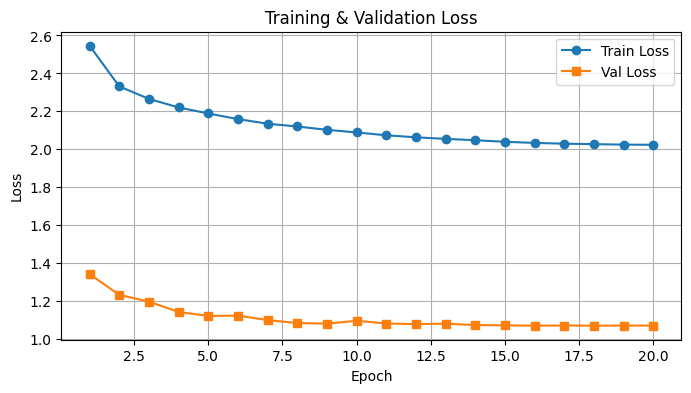

In [11]:
# ================================
# Plot Training vs Validation Loss
# ================================
plt.figure(figsize=(8,4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', label="Train Loss")
plt.plot(range(1, EPOCHS+1), val_losses, marker='s', label="Val Loss")
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# ================================
# TTA Inference on Test Set
# ================================
from torchvision.transforms import functional as Fv

def tta_identity(img): return val_transform(img)
def tta_hflip(img): return val_transform(Fv.hflip(img))
def tta_rot(img, deg=8): return val_transform(img.rotate(deg, resample=Image.BILINEAR))

tta_funcs = [tta_identity, tta_hflip, lambda img: tta_rot(img, 8), lambda img: tta_rot(img, -8)]

model_head.eval()
feature_model.eval()

tta_preds = []
for p in tqdm(X_test_paths, desc='TTA inference'):
    img = Image.open(p).convert('RGB')
    logits_list = []
    for fn in tta_funcs:
        inp = fn(img).unsqueeze(0).to(device)
        with torch.no_grad():
            feat = feature_model(inp).squeeze(0)
            logit = model_head(feat)
            logits_list.append(logit.cpu().numpy())
    avg_logits = np.mean(np.stack(logits_list, axis=0), axis=0)
    pred = int(np.argmax(avg_logits))
    tta_preds.append(pred)

pd.DataFrame({'tta_preds': tta_preds}).to_csv(os.path.join(FEATURE_CSV_DIR, 'tta_predictions.csv'), index=False)

TTA inference: 100%|██████████| 600/600 [06:23<00:00,  1.56it/s]


In [13]:
y_true, y_pred = np.array(y_test), np.array(tta_preds)
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

print("\nFinal Test Metrics after TTA:")
print(f'Accuracy  : {accuracy:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1 Score  : {f1:.4f}')


Final Test Metrics after TTA:
Accuracy  : 0.9800
Precision : 0.9802
Recall    : 0.9800
F1 Score  : 0.9800


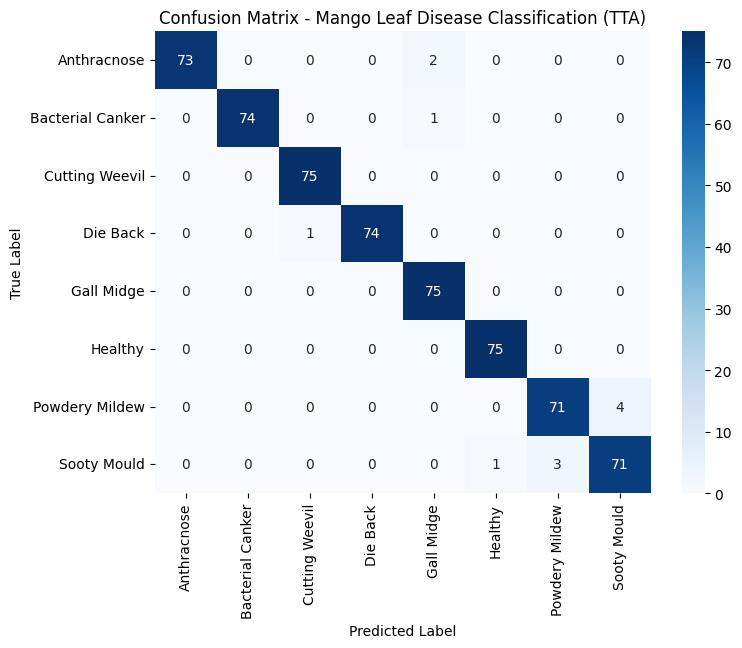

In [19]:
# ================================
# Confusion Matrix
# ================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Mango Leaf Disease Classification (TTA)")
plt.show()
